In [1]:
import igraph as ig
import numpy as np
from numpy.linalg import norm
import random
import pandas as pd
import scipy.io
import time
from IPython.display import display, clear_output
from operator import itemgetter
import matplotlib.pyplot as plt
from SOINN import ASOINN
from SOINN import SOINN_plus
from SOINN import SOINN_plus_v2
from SOINN import SOINN_plus_v3

In [2]:
def run_train(s):
    xs = []
    n_nodes = []
    n_edges = []
    n_del_nodes = []
    n_del_edges = []

    start_time = time.time()

    for index, row in train.iterrows():
        x = row.values
        y = y_train[index]
        s.fit_input_signal(x, y)
        # print completed percentage
        percent_completed = round((index / len(train))*100, 2)
        if index % 100 == 0 or index == len(train):
            clear_output(wait=True)
            print(f'Processing input {index}: {percent_completed}% completed')
            n_nodes.append(s.network.vcount())
            n_edges.append(s.network.ecount())
            n_del_nodes.append(s.n_del_nodes)
            n_del_edges.append(s.n_del_edges)
            xs.append(index)

    finish_time = round(time.time() - start_time)
    mins = round(finish_time / 60)
    secs = finish_time % 60

    clear_output(wait=True)
    print(f'Training time: {mins} min {secs} sec')
    print(f'Inputs processed: {index}')

    n_v = s.network.vcount()
    n_e = s.network.ecount()
    print(f'Number of nodes: {n_v}')
    print(f'Number of edges: {n_e}')

    return xs, n_nodes, n_edges, n_del_nodes, n_del_edges

In [3]:
def run_test(s):
    n_errors = 0
    n_false_alarms = 0
    n_non_detected_attacks = 0
    predicted = []

    for index, row in test.iterrows():
        x = row.values
        y = y_test[index]
        yp = s.predict(x)
        # append predicted label for later visualization
        predicted.append(yp)
        if y != yp:
            n_errors += 1
        if y != yp and (y == 'normal' and yp != 'normal'):
            n_false_alarms += 1
        if y != yp and (y != 'normal' and yp == 'normal'):
            n_non_detected_attacks += 1
        # print completed percentage
        percent_completed = round((index / len(test))*100, 2)
        if index % 100 == 0 or index == len(test):
            clear_output(wait=True)
            print(f'Predictions completed: {percent_completed}%')

    clear_output(wait=True)
    print(f'Inputs processed: {index}')
    p1 = round((1 - (n_errors / index))*100, 2)
    p2 = round((n_false_alarms / index)*100, 2)
    p3 = round((1 - (n_non_detected_attacks / index))*100, 2)
    print(f'Overall accuracy: {p1}%')
    print(f'False alarms: {p2}%')
    print(f'Detected attacks: {p3}%')

    errors_freq = dict()
    for i in range(len(y_test)):
        if y_test[i] != predicted[i]:
            errors_freq[f'{y_test[i]}-{predicted[i]}'] = 0

    for i in range(len(y_test)):
        if y_test[i] != predicted[i]:
            #print(f'Prediction given {y_test[i]}: {predicted[i]}')
            errors_freq[f'{y_test[i]}-{predicted[i]}'] += 1

    # sort frequency dictionary
    errors_freq = dict(sorted(errors_freq.items(), key=itemgetter(1)))
    print('\n\n')
    print(errors_freq)

# Dataset Importing

In [4]:
train = pd.read_csv('./NSL-KDD/KDDTrain+.txt', sep=',', header=None)
test = pd.read_csv('./NSL-KDD/KDDTest+.txt', sep=',', header=None)

# dropping first not necessary column
train.drop([0], axis=1, inplace=True)
test.drop([0], axis=1, inplace=True)

# shuffling training dataset
train = train.sample(frac=1).reset_index(drop=True)

# one-hot encoding for non-ordinal categorical variables (first three columns)
train = pd.get_dummies(train, columns=[1, 2, 3])
test = pd.get_dummies(test, columns=[1, 2, 3])

# adding columns present in train but not in test
extra_columns = []
for i in train.columns.values:
    if i not in test.columns.values:
        extra_columns.append(i)
for col in extra_columns:
    test[col] = 0

# reordering columns
train.columns.astype('string')
test.columns.astype('string')
cols = train.columns.tolist()
cols.sort()
train = train[cols]
test = test[cols]

y_train = train['41'].values
del train['41']
y_test = test['41'].values
del test['41']

# dropping the 'difficulty level' column
del train['42']
del test['42']

In [5]:
train.head()

,10,11,12,13,14,15,16,17,18,19,...,3_S3,3_SF,3_SH,4,40,5,6,7,8,9
0,0,1,0,0,0,0,0,0,0,0,...,0,1,0,246,0.0,1287,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1.0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,8,0.0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,1,0,219,0.0,2688,0,0,0,0


In [6]:
test.head()

,10,11,12,13,14,15,16,17,18,19,...,3_S3,3_SF,3_SH,4,40,5,6,7,8,9
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1.00,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1.00,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,12983,0.00,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,20,0.00,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.71,15,0,0,0,0


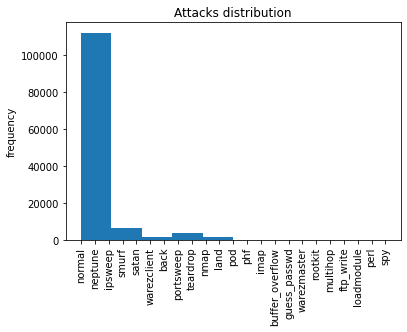

In [12]:
plt.hist(y_train)
plt.title('Attacks distribution')
plt.ylabel('frequency')
plt.xticks(rotation=90)
plt.show()

In [14]:
n_attack = 0
n_normal = 0

for c in y_train:
    if c == 'normal':
        n_normal += 1
    else:
        n_attack += 1

print(f'Attack traffic: {n_attack} connections')
print(f'Normal traffic: {n_normal} connections')

Attack traffic: 58630 connections
Normal traffic: 67343 connections


# ASOINN

In [7]:
rand_int = random.randint(1, len(train) - 1)
x1 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x2 = train.iloc[rand_int].values

s = ASOINN.ASOINN(x1, x2, lambda_iter=100, max_edge_age=50)

run_train(s)

Training time: 4 min 42 sec
Inputs processed: 125972
Number of nodes: 175
Number of edges: 197


In [8]:
run_test(s)

Inputs processed: 22543
Overall accuracy: 66.52%
False alarms: 1.76%
Detected attacks: 77.91%
{'sendmail-neptune': 1, 'rootkit-neptune': 1, 'warezmaster-nmap': 1, 'saint-nmap': 1, 'imap-normal': 1, 'ps-ipsweep': 1, 'loadmodule-normal': 2, 'ipsweep-neptune': 2, 'worm-normal': 2, 'perl-normal': 2, 'sendmail-ipsweep': 2, 'land-neptune': 2, 'warezmaster-satan': 2, 'sqlattack-normal': 2, 'xlock-warezclient': 2, 'udpstorm-normal': 2, 'phf-normal': 2, 'satan-ipsweep': 2, 'neptune-ipsweep': 2, 'normal-warezclient': 3, 'snmpguess-ipsweep': 3, 'teardrop-ipsweep': 3, 'ftp_write-normal': 3, 'teardrop-normal': 3, 'multihop-neptune': 4, 'xsnoop-normal': 4, 'named-pod': 4, 'portsweep-satan': 5, 'pod-normal': 5, 'land-normal': 5, 'satan-normal': 6, 'teardrop-neptune': 6, 'mscan-satan': 7, 'xlock-normal': 7, 'normal-satan': 10, 'nmap-satan': 10, 'warezmaster-neptune': 10, 'sendmail-normal': 11, 'rootkit-normal': 12, 'nmap-neptune': 13, 'named-normal': 13, 'xterm-normal': 13, 'ps-normal': 14, 'multihop-

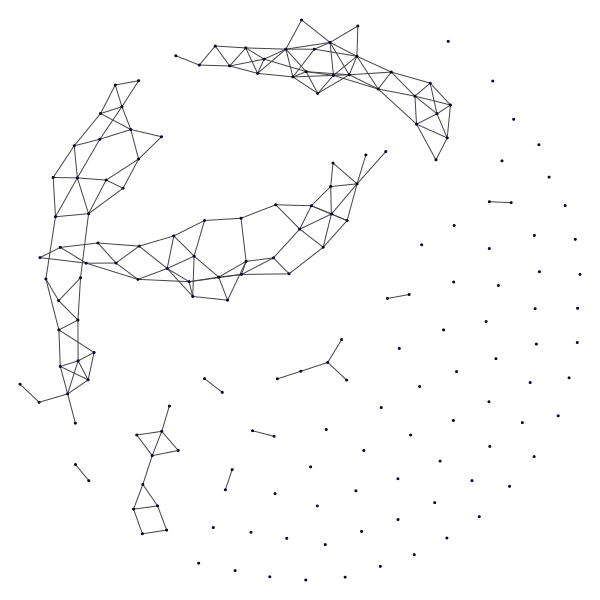

In [9]:
s.network.layout(layout='kk')
ig.plot(s.network, vertex_size=2, vertex_color=['blue'])

# SOINN+

In [10]:
rand_int = random.randint(1, len(train) - 1)
x1 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x2 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x3 = train.iloc[rand_int].values

s = SOINN_plus.SOINN_plus(x1, x2, x3)

run_train(s)

Training time: 4 min 7 sec
Inputs processed: 125972
Number of nodes: 315
Number of edges: 151


In [11]:
run_test(s)

Inputs processed: 22543
Overall accuracy: 68.73%
False alarms: 2.39%
Detected attacks: 81.25%
{'mscan-nmap': 1, 'teardrop-normal': 1, 'sendmail-portsweep': 1, 'rootkit-neptune': 1, 'xlock-back': 1, 'imap-normal': 1, 'udpstorm-ipsweep': 1, 'ftp_write-neptune': 1, 'httptunnel-back': 1, 'satan-normal': 1, 'named-warezclient': 1, 'land-normal': 1, 'udpstorm-portsweep': 1, 'sendmail-ipsweep': 2, 'loadmodule-normal': 2, 'ipsweep-portsweep': 2, 'worm-normal': 2, 'perl-normal': 2, 'land-portsweep': 2, 'teardrop-ipsweep': 2, 'sqlattack-normal': 2, 'ftp_write-normal': 2, 'mscan-teardrop': 2, 'teardrop-portsweep': 2, 'phf-normal': 2, 'named-back': 2, 'neptune-portsweep': 2, 'neptune-satan': 2, 'satan-ipsweep': 3, 'snmpguess-ipsweep': 3, 'multihop-portsweep': 4, 'named-ipsweep': 4, 'xsnoop-normal': 4, 'teardrop-neptune': 4, 'land-ipsweep': 4, 'ipsweep-normal': 5, 'portsweep-ipsweep': 6, 'portsweep-normal': 6, 'nmap-ipsweep': 7, 'saint-portsweep': 8, 'warezmaster-portsweep': 8, 'xlock-normal': 8, '

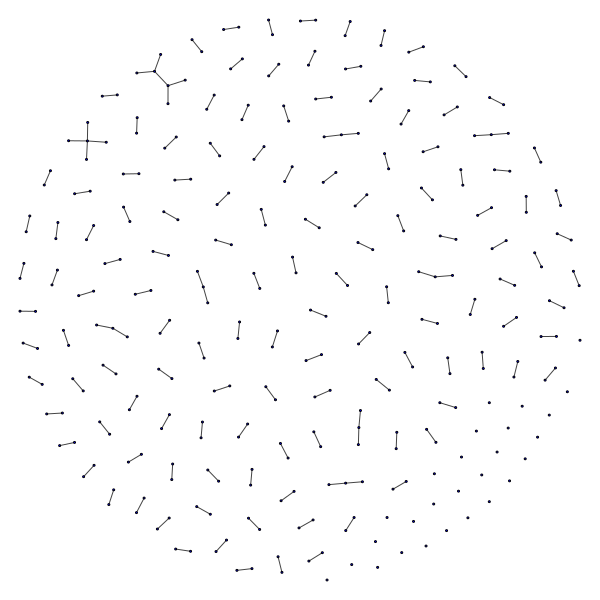

In [12]:
ig.plot(s.network, vertex_size=2, vertex_color=['blue'])

# SOINN v2

In [13]:
rand_int = random.randint(1, len(train) - 1)
x1 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x2 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x3 = train.iloc[rand_int].values

s = SOINN_plus_v2.SOINN_plus(x1, x2, x3)

run_train(s)

Training time: 14 min 10 sec
Inputs processed: 125972
Number of nodes: 1376
Number of edges: 604


In [14]:
run_test(s)

Inputs processed: 22543
Overall accuracy: 69.06%
False alarms: 1.74%
Detected attacks: 79.25%
{'portsweep-normal': 1, 'satan-normal': 1, 'neptune-teardrop': 1, 'xlock-back': 1, 'snmpgetattack-guess_passwd': 1, 'imap-normal': 1, 'multihop-guess_passwd': 1, 'ftp_write-satan': 1, 'normal-smurf': 1, 'httptunnel-back': 1, 'named-warezclient': 1, 'land-nmap': 1, 'neptune-nmap': 1, 'httptunnel-warezclient': 1, 'saint-portsweep': 2, 'loadmodule-normal': 2, 'ipsweep-portsweep': 2, 'worm-normal': 2, 'named-ipsweep': 2, 'perl-normal': 2, 'land-portsweep': 2, 'sqlattack-normal': 2, 'xlock-warezclient': 2, 'ftp_write-normal': 2, 'udpstorm-normal': 2, 'phf-normal': 2, 'named-back': 2, 'satan-ipsweep': 2, 'sendmail-ipsweep': 3, 'snmpguess-ipsweep': 3, 'teardrop-ipsweep': 3, 'teardrop-normal': 3, 'named-pod': 3, 'warezmaster-satan': 4, 'xsnoop-normal': 4, 'teardrop-neptune': 4, 'land-normal': 4, 'httptunnel-ipsweep': 5, 'portsweep-satan': 5, 'xlock-normal': 6, 'pod-normal': 7, 'portsweep-neptune': 8, 

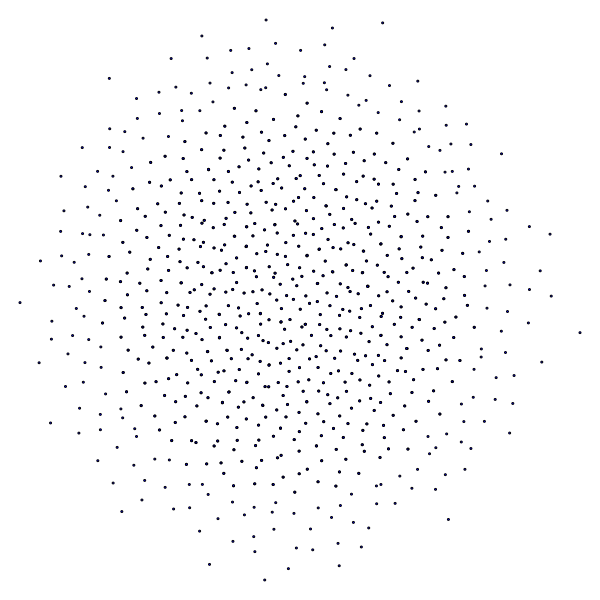

In [15]:
s.network.layout(layout='kk')
ig.plot(s.network, vertex_size=2, vertex_color=['blue'])

# SOINN v3

In [30]:
rand_int = random.randint(1, len(train) - 1)
x1 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x2 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x3 = train.iloc[rand_int].values

s = SOINN_plus_v3.SOINN_plus(x1, x2, x3, iter_edge_del=800)

xs, n_nodes, n_edges, n_del_nodes, n_del_edges = run_train(s)

Training time: 4 min 11 sec
Inputs processed: 125972
Number of nodes: 377
Number of edges: 491


In [31]:
run_test(s)

Inputs processed: 22543
Overall accuracy: 68.58%
False alarms: 1.72%
Detected attacks: 81.34%



{'satan-nmap': 1, 'teardrop-ipsweep': 1, 'sendmail-portsweep': 1, 'sendmail-ipsweep': 1, 'snmpguess-land': 1, 'imap-normal': 1, 'warezmaster-portsweep': 1, 'udpstorm-land': 1, 'warezmaster-neptune': 1, 'ftp_write-ipsweep': 1, 'warezmaster-teardrop': 1, 'httptunnel-back': 1, 'multihop-satan': 1, 'land-normal': 1, 'udpstorm-nmap': 1, 'teardrop-neptune': 1, 'sendmail-land': 2, 'loadmodule-normal': 2, 'ipsweep-nmap': 2, 'warezmaster-nmap': 2, 'worm-normal': 2, 'neptune-nmap': 2, 'perl-normal': 2, 'rootkit-back': 2, 'land-portsweep': 2, 'teardrop-land': 2, 'sqlattack-normal': 2, 'normal-warezclient': 2, 'ftp_write-normal': 2, 'normal-smurf': 2, 'teardrop-nmap': 2, 'neptune-ipsweep': 2, 'phf-normal': 2, 'satan-land': 2, 'multihop-portsweep': 3, 'named-back': 3, 'guess_passwd-ipsweep': 3, 'teardrop-portsweep': 3, 'named-land': 4, 'satan-ipsweep': 4, 'xsnoop-normal': 4, 'saint-land': 4, 'xlock-norm

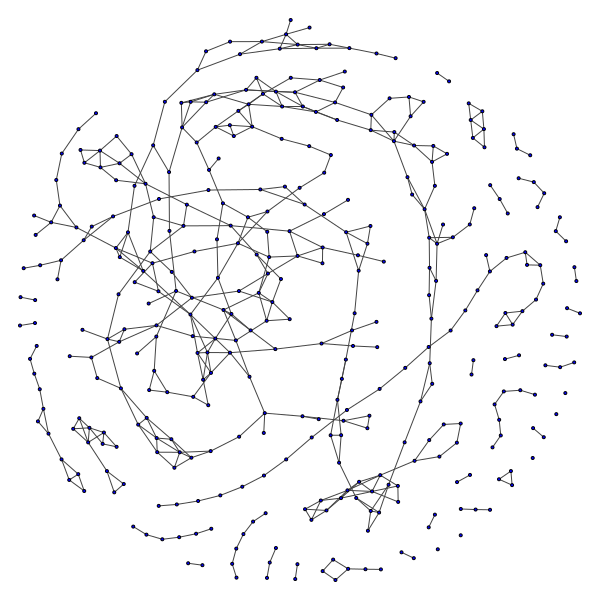

In [32]:
s.network.layout(layout='kk')
ig.plot(s.network, vertex_size=3, vertex_color=['blue'])

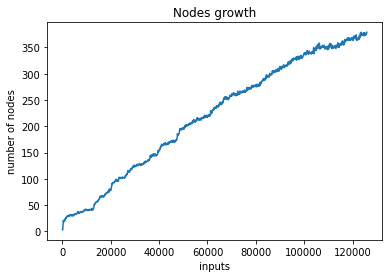

In [33]:
plt.plot(xs, n_nodes)
plt.title('Nodes growth')
plt.xlabel('inputs')
plt.ylabel('number of nodes')
plt.show()

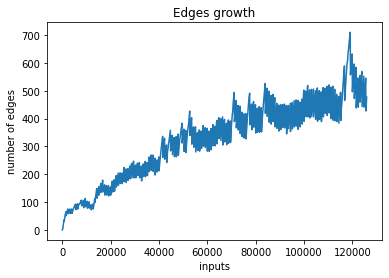

In [34]:
plt.plot(xs, n_edges)
plt.title('Edges growth')
plt.xlabel('inputs')
plt.ylabel('number of edges')
plt.show()

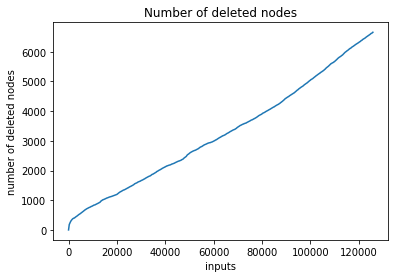

In [35]:
plt.plot(xs, n_del_nodes)
plt.title('Number of deleted nodes')
plt.xlabel('inputs')
plt.ylabel('number of deleted nodes')
plt.show()

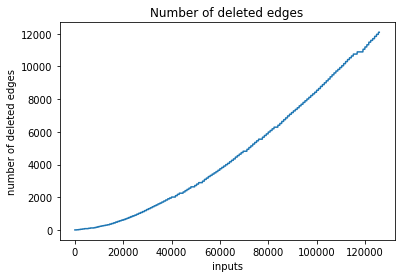

In [36]:
plt.plot(xs, n_del_edges)
plt.title('Number of deleted edges')
plt.xlabel('inputs')
plt.ylabel('number of deleted edges')
plt.show()

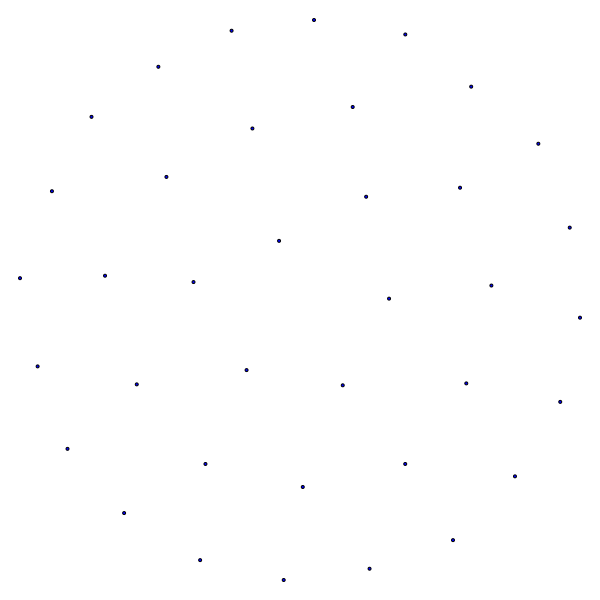

In [37]:
vc = s.network.components()
gc = vc.cluster_graph()

gc.layout(layout='kk')
ig.plot(gc, vertex_size=3, vertex_color=['blue'])

In [38]:
print(f'Number of clusters: {gc.vcount()}')

Number of clusters: 37
